In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

# Eksperimen 0: Grayscale Langsung Ekstraksi (Tanpa Preprocessing Tambahan)

Pada eksperimen ini, citra hanya melalui proses **grayscale** (saat data dimuat) dan **resize** ke ukuran 128x128, tanpa preprocessing tambahan (tanpa histogram equalization, blur, CLAHE, thresholding, dll). Hasil grayscale tersebut langsung diekstraksi fitur GLCM-nya.

## Data Loading

Struktur folder dataset:
```
.
└──meat
    ├── FreshMeat
    │   ├── 0001.jpg
    │   ├── 0002.jpg
    │   └── ...
    └── RottenMeat
        ├── 0001.jpg
        └── ...
```

In [2]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("meat\\"):
    sub_folder_files = os.listdir(os.path.join("meat\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("meat\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # Konversi ke grayscale

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

print("Total data:", len(data))
print("Label unik:", np.unique(labels))

Total data: 2000
Label unik: ['FreshMeat' 'RottenMeat']


## Eksperimen 0: Resize + Grayscale (Tanpa Preprocessing Tambahan)

In [3]:
def resize(image, target_size=(128, 128)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def show_samples(images, title):
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')
    plt.show()

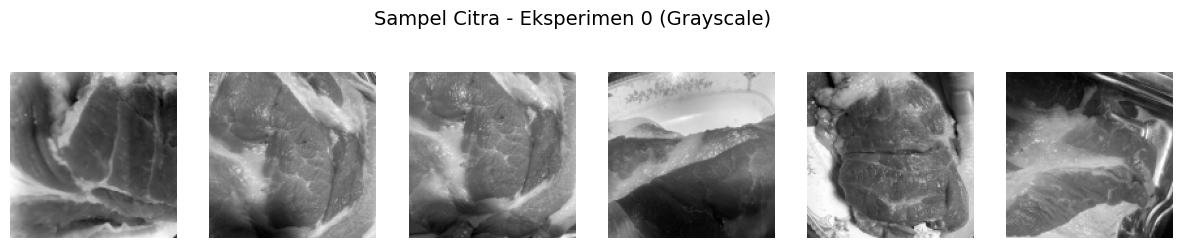

Total citra yang siap diekstrak GLCM: 2000


In [4]:
# Eksperimen 0: hanya grayscale (sudah dilakukan saat load) + resize, tanpa preprocessing tambahan
dataPreprocessed = []
for img in data:
    img_resized = resize(img, (128, 128))
    dataPreprocessed.append(img_resized)

show_samples(dataPreprocessed[:6], "Sampel Citra - Eksperimen 0 (Grayscale)")
print("Total citra yang siap diekstrak GLCM:", len(dataPreprocessed))

## Feature Extraction (GLCM)

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [6]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    Derajat0.append(glcm(dataPreprocessed[i], 0))
    Derajat45.append(glcm(dataPreprocessed[i], 45))
    Derajat90.append(glcm(dataPreprocessed[i], 90))
    Derajat135.append(glcm(dataPreprocessed[i], 135))

In [7]:
# List penampung fitur untuk setiap sudut
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

### Simpan Hasil Ekstraksi ke CSV

In [8]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_eksperimen0.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_eksperimen0.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,FreshMeat,56.806348,116.514787,74.042876,116.205220,0.229553,0.186595,0.240227,0.176014,...,0.000615,0.000421,0.023853,0.021717,0.024804,0.020522,0.980486,0.959343,0.974475,0.959446
1,0002.jpg,FreshMeat,109.377645,128.761114,97.366757,181.762416,0.180901,0.154931,0.174925,0.138745,...,0.000425,0.000341,0.020255,0.018918,0.020614,0.018468,0.960789,0.953454,0.964928,0.934293
2,0003.jpg,FreshMeat,85.613927,136.921818,91.065822,137.333065,0.194652,0.154607,0.177317,0.144920,...,0.000396,0.000323,0.020215,0.018130,0.019891,0.017963,0.967721,0.948054,0.965576,0.947906
3,0004.jpg,FreshMeat,55.073511,161.966830,115.227362,114.415401,0.309247,0.222291,0.261711,0.241174,...,0.000435,0.000381,0.023180,0.019215,0.020860,0.019508,0.993300,0.980236,0.985902,0.986037
4,0005.jpg,FreshMeat,215.743848,255.738979,190.373954,372.984934,0.147835,0.133774,0.167988,0.119270,...,0.000275,0.000199,0.015764,0.015015,0.016576,0.014121,0.957548,0.949442,0.962668,0.926268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0996.jpg,RottenMeat,466.095534,660.169756,263.259104,626.017670,0.134617,0.109921,0.174489,0.107633,...,0.000242,0.000156,0.013713,0.012453,0.015562,0.012495,0.923600,0.891150,0.956725,0.896779
1996,0997.jpg,RottenMeat,274.045768,674.454709,520.325910,714.187984,0.144633,0.088924,0.111889,0.086874,...,0.000161,0.000135,0.014566,0.011710,0.012684,0.011610,0.943082,0.858858,0.891438,0.850518
1997,0998.jpg,RottenMeat,521.295337,700.640523,259.198204,657.547213,0.111104,0.089197,0.144963,0.089365,...,0.000214,0.000139,0.012813,0.011760,0.014640,0.011796,0.891902,0.853927,0.946373,0.862910
1998,0999.jpg,RottenMeat,434.845288,580.112964,326.750923,688.708041,0.122990,0.092906,0.118246,0.085176,...,0.000155,0.000125,0.012766,0.011275,0.012447,0.011174,0.926949,0.902364,0.945167,0.884108


## Splitting Data

In [9]:
X = hasilEkstrak.drop(columns=['Label', 'Filename'])
y = hasilEkstrak['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1600, 28)
(400, 28)


## Feature Normalization

In [10]:
# Normalisasi Mean-Std (Standardization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

### Define Model

In [11]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [12]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

   FreshMeat       1.00      0.99      0.99       801
  RottenMeat       0.99      1.00      0.99       799

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

[[792   9]
 [  3 796]]
Accuracy: 0.9925

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.93      0.91      0.92       199
  RottenMeat       0.91      0.93      0.92       201

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[181  18]
 [ 14 187]]
Accuracy: 0.92


### Train SVM Classifier

In [13]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.95      0.94      0.94       801
  RottenMeat       0.94      0.95      0.94       799

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

[[752  49]
 [ 40 759]]
Accuracy: 0.944375

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.93      0.92      0.93       199
  RottenMeat       0.92      0.94      0.93       201

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

[[183  16]
 [ 13 188]]
Accuracy: 0.9275


### Train KNN Classifier

In [14]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.97      0.97      0.97       801
  RottenMeat       0.97      0.97      0.97       799

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

[[777  24]
 [ 20 779]]
Accuracy: 0.9725

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.95      0.95      0.95       199
  RottenMeat       0.96      0.96      0.96       201

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400

[[190   9]
 [  9 192]]
Accuracy: 0.955


## Evaluation With Confusion Matrix

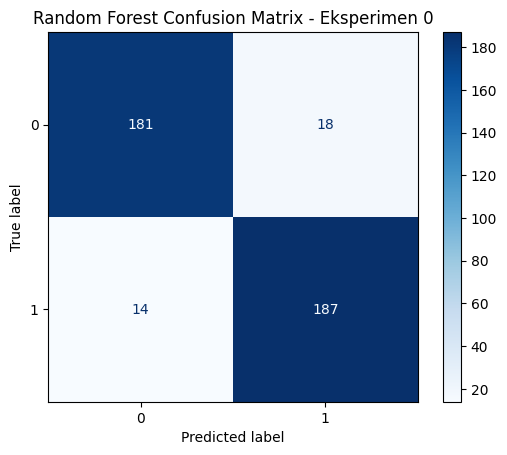

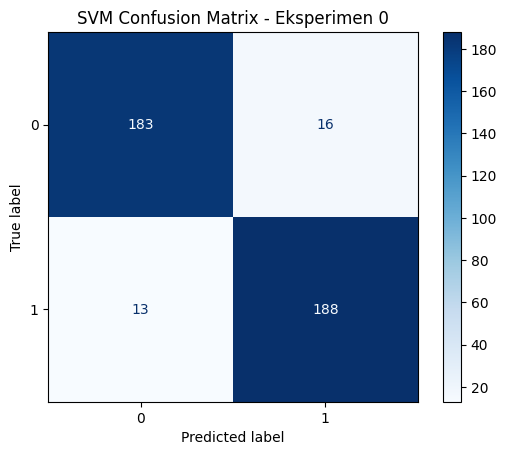

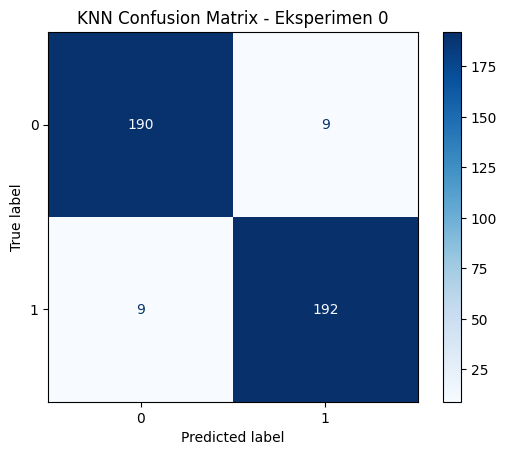

In [15]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix untuk Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix - Eksperimen 0")
# Plot confusion matrix untuk SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Eksperimen 0")
# Plot confusion matrix untuk KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Eksperimen 0")

## Ringkasan Akurasi Eksperimen 0

In [16]:
results_eksperimen0 = {
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Akurasi (%)': [
        accuracy_score(y_test, rf.predict(X_test)) * 100,
        accuracy_score(y_test, svm.predict(X_test)) * 100,
        accuracy_score(y_test, knn.predict(X_test)) * 100,
    ]
}
df_results0 = pd.DataFrame(results_eksperimen0)
df_results0['Akurasi (%)'] = df_results0['Akurasi (%)'].map(lambda x: f"{x:.2f}")
print("=== Hasil Akurasi Eksperimen 0 (Grayscale, Tanpa Preprocessing Tambahan) ===")
display(df_results0)

=== Hasil Akurasi Eksperimen 0 (Grayscale, Tanpa Preprocessing Tambahan) ===


,Model,Akurasi (%)
0,Random Forest,92.00
1,SVM,92.75
2,KNN,95.50
